ARTI308 - Machine Learning

# Linear Regression on Ecommerce Customers Dataset

In this lab , we apply **Linear Regression** to a new dataset not mine **Ecommerce Customers**.  
The goal is to build a model that can predict **Yearly Amount Spent** based on customer behavior features.

The dataset contains the following columns:

* `Email`: Customer email address
* `Address`: Customer address
* `Avatar`: Preferred avatar color
* `Avg. Session Length`: Average session length of in-store style advice sessions
* `Time on App`: Average time spent on the mobile app
* `Time on Website`: Average time spent on the website
* `Length of Membership`: Number of years the customer has been a member
* `Yearly Amount Spent`: Amount the customer spends in a year


**Let's gooo hhh**
## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Load the Dataset

In [2]:
customers = pd.read_csv('Ecommerce Customers')
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## Explore the Data

In [3]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
customers.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

## Basic Data Cleaning

Check for missing values and duplicated rows.

In [6]:
customers.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [7]:
customers.duplicated().sum()

np.int64(0)

There are no missing values and no duplicated rows, so the dataset is already clean.

## Exploratory Data Analysis (EDA)

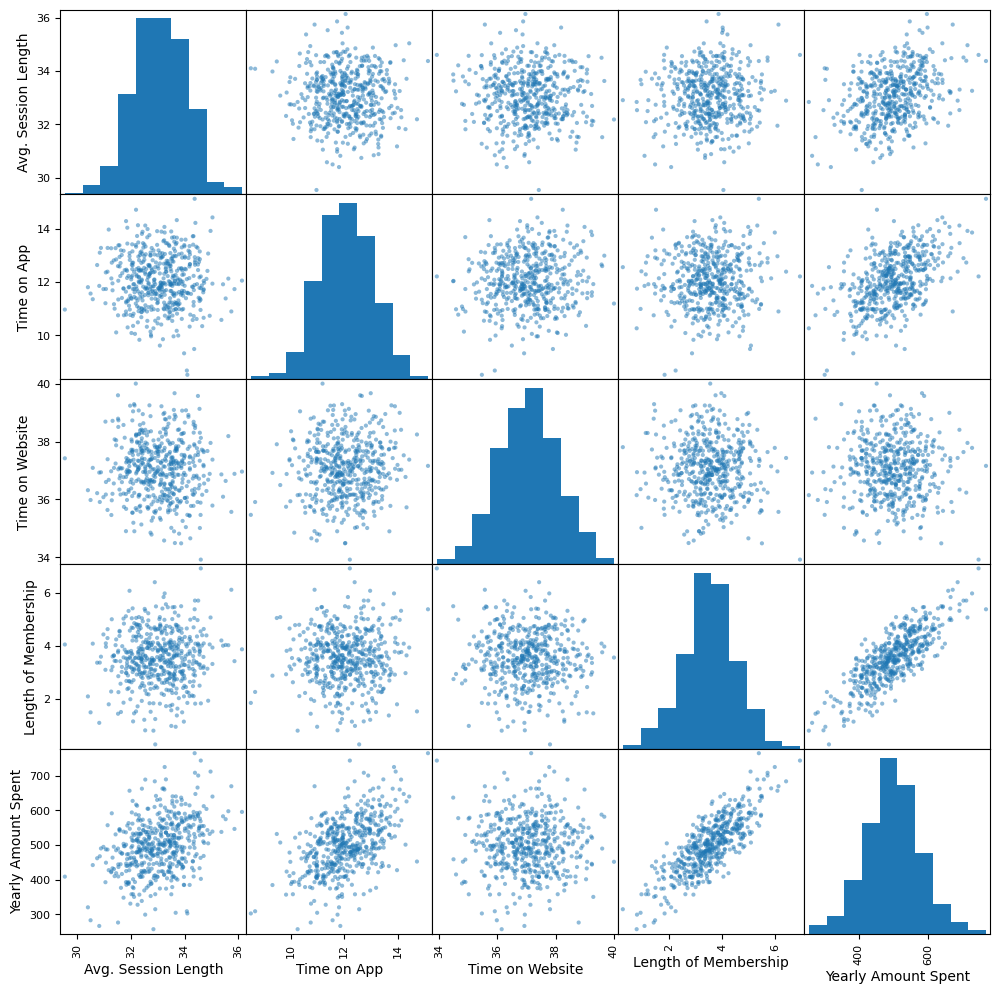

In [8]:
from pandas.plotting import scatter_matrix
scatter_matrix(customers.select_dtypes(include='number'), figsize=(12, 12));

Text(0.5, 1.0, 'Distribution of Yearly Amount Spent')

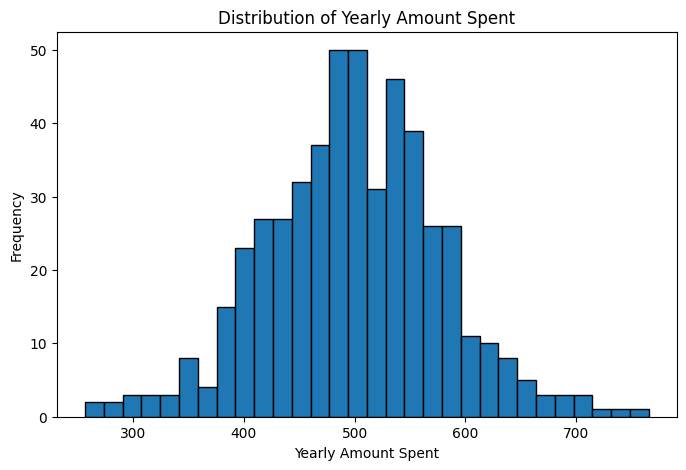

In [9]:
plt.figure(figsize=(8,5))
plt.hist(customers['Yearly Amount Spent'], bins=30, edgecolor='black')
plt.xlabel('Yearly Amount Spent')
plt.ylabel('Frequency')
plt.title('Distribution of Yearly Amount Spent')

<Axes: >

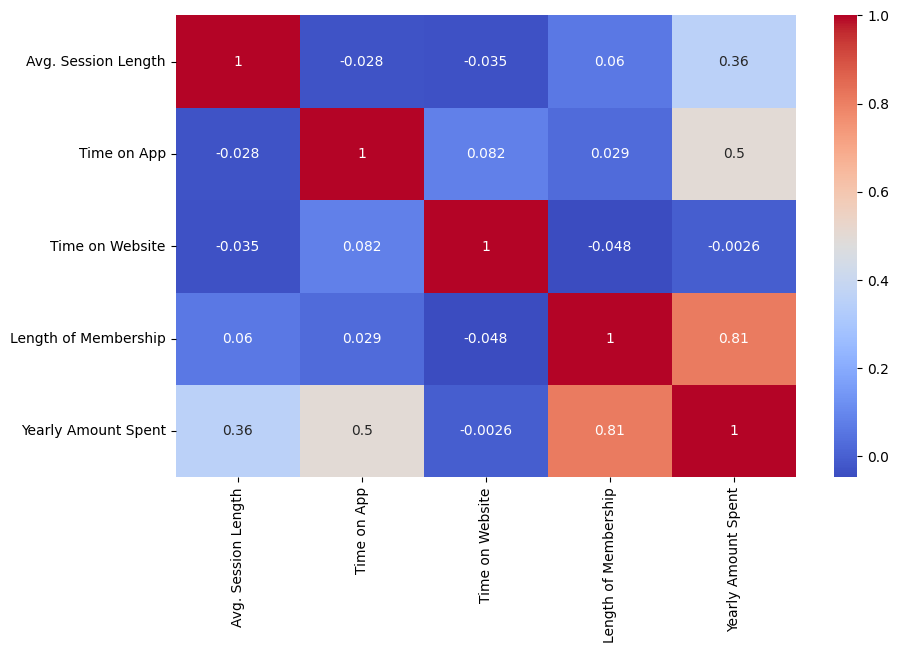

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(customers.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

## Feature Engineering

The columns `Email`, `Address`, and `Avatar` are text columns and will not be used in the Linear Regression model.
We will use the numeric behavior-related features to predict `Yearly Amount Spent`.

## Prepare X and y Arrays

In [11]:
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = customers['Yearly Amount Spent']

## Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## Create and Train the Model

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lm = LinearRegression()

In [16]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Evaluation

In [17]:
print(lm.intercept_)

-1047.9327822502391


In [18]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


### Interpreting the Coefficients

 - A positive coefficient means that as the feature increases, **Yearly Amount Spent** tends to increase.
 --A negative coefficient means that as the feature increases **Yearly Amount Spent** tends to decrease
 - The feature with the largest positive effect is usually **Length of Membership**, which means loyal customers tend to spend more


## Predictions from our Model

In [19]:
predictions = lm.predict(X_test)

Text(0, 0.5, 'Predicted Y')

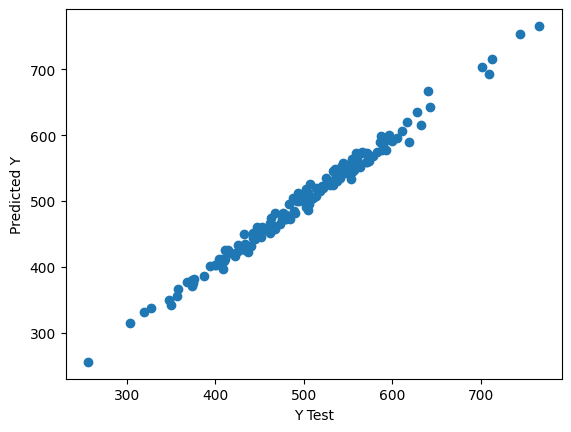

In [20]:
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Residual Histogram

Text(0.5, 1.0, 'Residual Histogram')

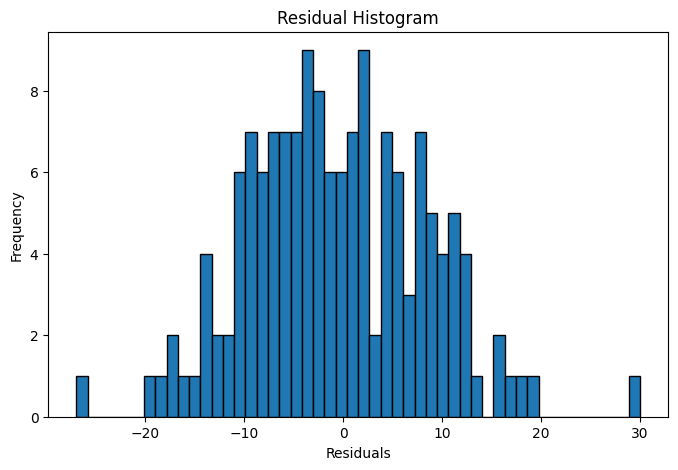

In [21]:
plt.figure(figsize=(8,5))
plt.hist((y_test - predictions), bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Histogram')

## Regression Evaluation Metrics

We will use three common metrics for regression:

- **MAE**: Mean Absolute Error
- **MSE**: Mean Squared Error
- **RMSE**: Root Mean Squared Error


In [22]:
from sklearn import metrics

In [23]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.228148653430826
MSE: 79.81305165097427
RMSE: 8.933815066978624


## Final Conclusion

This lab applies **Linear Regression** to the **Ecommerce Customers** dataset .
The model predicts **Yearly Amount Spent** using customer activity features.
Based on the results, the model performs well, and customer membership length appears to be one of the strongest predictors of yearly spending.
